# 02 — Pay Profiles

Build the basic pay progression for all three career profiles through
each profile's maximum career length. Compute the High-Three base
(average of the highest 36 months of monthly basic pay) for each
profile x separation scenario combination.

**Inputs:** `data/processed/basic_pay.csv`,
`data/processed/promotion_timing.csv`  
**Outputs:** `data/processed/pay_profiles.csv`,
`data/processed/high_three_matrix.csv`

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path("../src")))
from pay_builder import build_pay_series  # noqa: E402
from pension_calcs import high_three_base  # noqa: E402

PROCESSED = Path("../data/processed")

## Model constants

In [2]:
PROFILES = ["Officer", "Enlisted", "PriorEnlistedOfficer"]
# Display order for cross-profile tables and charts
PROFILE_ORDER = [
    "Enlisted", "PriorEnlistedOfficer", "Officer"
]

# Uniform 2-year grid to the statutory service maxima
# (officer 40 / enlisted 30), matching 03a/03b/04
# (52 scenarios)
PROFILE_SCENARIOS = {
    "Officer": list(range(4, 41, 2)),
    "Enlisted": list(range(4, 31, 2)),
    "PriorEnlistedOfficer": list(range(4, 41, 2)),
}


## Load processed data

In [3]:
basic_pay = pd.read_csv(
    PROCESSED / "basic_pay.csv", index_col="PayGrade"
)
basic_pay.columns = basic_pay.columns.astype(int)

promotion = pd.read_csv(PROCESSED / "promotion_timing.csv")
promotion = promotion.set_index("YOS")

print(
    f"Basic pay: {basic_pay.shape}"
    " (pay grades x YOS breakpoints)"
)
print(
    f"Promotion timing: {promotion.shape}"
    " (YOS rows x profile columns)"
)

Basic pay: (22, 22) (pay grades x YOS breakpoints)
Promotion timing: (40, 3) (YOS rows x profile columns)


## Pay lookup helpers

`build_pay_series` (imported from `src/pay_builder.py`, where it is
shared with the interactive app) assembles the full monthly pay
sequence for a profile through separation, using `lookup_pay` to map
each (grade, YOS) to the highest applicable pay table breakpoint.

## Build full career pay series per profile

In [4]:
records = []

for profile in PROFILES:
    max_yos = promotion[profile].dropna().index.max()
    series = build_pay_series(
        profile, max_yos, promotion, basic_pay
    )
    for yos, monthly_pay in series.items():
        records.append(
            {
                "Profile": profile,
                "YOS": yos,
                "MonthlyPay": monthly_pay,
            }
        )

pay_profiles = pd.DataFrame(records)
profile_max = pay_profiles.groupby("Profile")["YOS"].max()
print(f"Total rows: {pay_profiles.shape[0]}")
print("\nMax YOS per profile:")
print(profile_max.to_string())
pay_profiles.head(10)

Total rows: 110

Max YOS per profile:
Profile
Enlisted                30
Officer                 40
PriorEnlistedOfficer    40


,Profile,YOS,MonthlyPay
0,Officer,1,4150.2
1,Officer,2,5446.2
2,Officer,3,6272.4
3,Officer,4,7382.7
4,Officer,5,7382.7
5,Officer,6,7737.0
6,Officer,7,7737.0
7,Officer,8,8125.5
8,Officer,9,8125.5
9,Officer,10,9420.0


## Spot-checks

Officer at 20 YOS retires as O-5; enlisted at 20 YOS retires as E-8.
High-Three base should reflect the 3 highest-earning years (typically
the final 3, since pay generally increases over a career).

In [5]:
def check_scenario(profile, sep_yos):
    series = pay_profiles.query(
        "Profile == @profile and YOS <= @sep_yos"
    ).set_index("YOS")["MonthlyPay"]
    h3 = high_three_base(series)
    annual = h3 * 12 * 0.025 * sep_yos
    print(f"\n{profile}, sep YOS {sep_yos}")
    print("  Final 5 years of pay (monthly):")
    for yos, pay in series.tail(5).items():
        print(f"    YOS {yos:>2}: ${pay:>9,.2f}")
    print(f"  High-Three base (monthly):  ${h3:>9,.2f}")
    print(
        f"  Annual High-Three pension"
        f" (2.5% x {sep_yos} YOS): ${annual:>10,.0f}"
    )


check_scenario("Enlisted", 20)
check_scenario("PriorEnlistedOfficer", 20)
check_scenario("Officer", 20)
check_scenario("Officer", 36)


Enlisted, sep YOS 20
  Final 5 years of pay (monthly):
    YOS 16: $ 6,000.90
    YOS 17: $ 6,448.20
    YOS 18: $ 6,811.20
    YOS 19: $ 6,811.20
    YOS 20: $ 6,995.40
  High-Three base (monthly):  $ 6,872.60
  Annual High-Three pension (2.5% x 20 YOS): $    41,236

PriorEnlistedOfficer, sep YOS 20
  Final 5 years of pay (monthly):
    YOS 16: $ 9,004.20
    YOS 17: $ 9,004.20
    YOS 18: $10,509.90
    YOS 19: $10,509.90
    YOS 20: $10,509.90
  High-Three base (monthly):  $10,509.90
  Annual High-Three pension (2.5% x 20 YOS): $    63,059

Officer, sep YOS 20
  Final 5 years of pay (monthly):
    YOS 16: $11,391.30
    YOS 17: $11,391.30
    YOS 18: $11,713.80
    YOS 19: $11,713.80
    YOS 20: $12,032.70
  High-Three base (monthly):  $11,820.10
  Annual High-Three pension (2.5% x 20 YOS): $    70,921

Officer, sep YOS 36
  Final 5 years of pay (monthly):
    YOS 32: $18,999.90
    YOS 33: $18,999.90
    YOS 34: $18,999.90
    YOS 35: $18,999.90
    YOS 36: $18,999.90
  High-Three

## High-Three base matrix

Monthly basic pay average of the 3 highest-earning years, by profile
and separation scenario. This is the pension base used in both the
High-Three and BRS pension formulas.

In [6]:
h3_records = []
for profile in PROFILES:
    for sep_yos in PROFILE_SCENARIOS[profile]:
        if sep_yos > profile_max[profile]:
            continue
        subset = pay_profiles.query(
            "Profile == @profile and YOS <= @sep_yos"
        )
        series = subset.set_index("YOS")["MonthlyPay"]
        h3_records.append(
            {
                "Profile": profile,
                "SepYOS": sep_yos,
                "High3Monthly": high_three_base(series),
            }
        )

h3_df = pd.DataFrame(h3_records)
h3_matrix = h3_df.pivot(
    index="Profile",
    columns="SepYOS",
    values="High3Monthly",
).reindex(PROFILE_ORDER)
h3_matrix.columns.name = None

print("High-Three base (monthly $), rounded to whole dollars:")
print(h3_matrix.round(0).to_string())

High-Three base (monthly $), rounded to whole dollars:
                          4       6       8       10      12      14       16       18       20       22       24       26       28       30       32       34       36       38       40
Profile                                                                                                                                                                                  
Enlisted              3290.0  3809.0  4173.0  4557.0  4854.0  5490.0   5890.0   6420.0   6873.0   7841.0   8534.0   8927.0   9268.0   9422.0      NaN      NaN      NaN      NaN      NaN
PriorEnlistedOfficer  3290.0  3809.0  4173.0  5380.0  7341.0  8860.0   9004.0   9506.0  10510.0  10510.0  11138.0  12395.0  12395.0  13399.0  15408.0  15408.0  16020.0  17242.0  18414.0
Officer               6367.0  7501.0  7866.0  8557.0  9576.0  9997.0  10607.0  11499.0  11820.0  12726.0  14235.0  14716.0  15761.0  17017.0  18414.0  19000.0  19000.0  19000.0  19000.0


## Visualizations

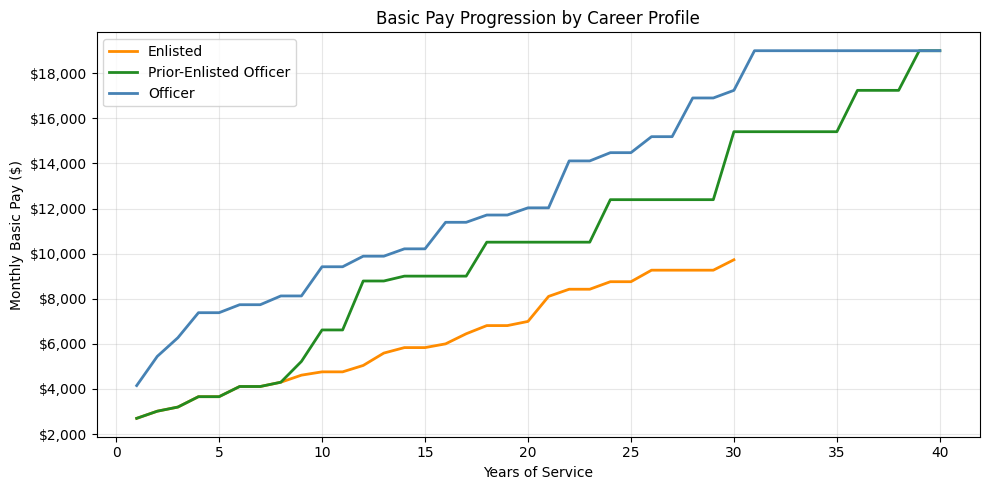

In [7]:
profile_styles = {
    "Enlisted": ("darkorange", "Enlisted"),
    "PriorEnlistedOfficer": (
        "forestgreen", "Prior-Enlisted Officer"
    ),
    "Officer": ("steelblue", "Officer"),
}

fig, ax = plt.subplots(figsize=(10, 5))

for profile, (color, label) in profile_styles.items():
    series = pay_profiles.query(
        "Profile == @profile"
    ).set_index("YOS")["MonthlyPay"]
    ax.plot(
        series.index, series.values,
        label=label, color=color, linewidth=2,
    )

ax.set_xlabel("Years of Service")
ax.set_ylabel("Monthly Basic Pay ($)")
ax.set_title("Basic Pay Progression by Career Profile")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}")
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

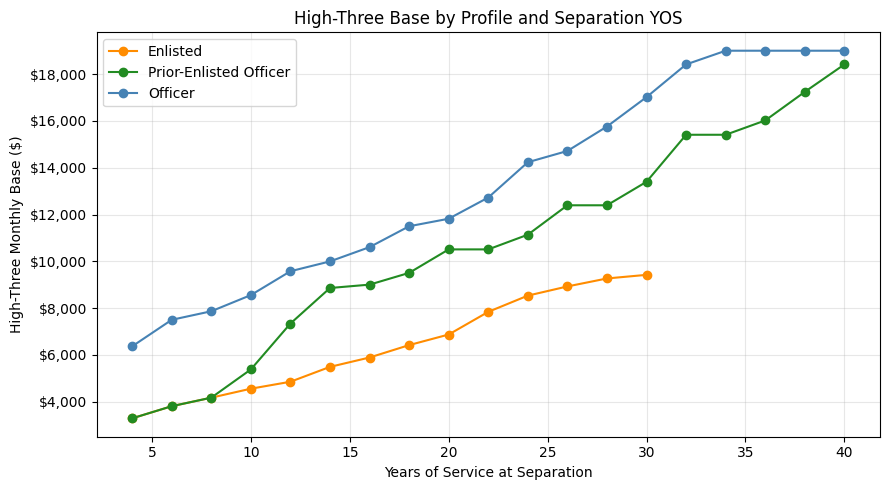

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

for profile, (color, label) in profile_styles.items():
    row = h3_matrix.loc[profile].dropna()
    ax.plot(
        row.index, row.values,
        marker="o", label=label, color=color,
    )

ax.set_xlabel("Years of Service at Separation")
ax.set_ylabel("High-Three Monthly Base ($)")
ax.set_title(
    "High-Three Base by Profile and Separation YOS"
)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}")
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Save outputs

In [9]:
pay_profiles.to_csv(
    PROCESSED / "pay_profiles.csv", index=False
)
h3_matrix.to_csv(PROCESSED / "high_three_matrix.csv")

print("Saved to data/processed/:")
for fname in ["pay_profiles.csv", "high_three_matrix.csv"]:
    p = PROCESSED / fname
    size_kb = p.stat().st_size / 1024
    print(f"  {fname:<30} {size_kb:>6.1f} KB")

Saved to data/processed/:
  pay_profiles.csv                  2.6 KB
  high_three_matrix.csv             0.7 KB
